# Polynomial Regression Task

---
## 1. Introduction & Task Overview
In this task, we explore the non-linear relationship between a car's **horsepower** and its fuel efficiency (**MPG**). We will fit polynomial models of various degrees (Degree 1, 2, and 10) to observe and diagnose the phenomena of **Underfitting** and **Overfitting**, finding the right balance for generalization on unseen data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Set visual style for plots
sns.set_theme(style="whitegrid")

## 2. Dataset Loading & Preprocessing
We fetch the dataset directly from the UCI Machine Learning Repository, handle missing values denoted by '?', and select our target and feature variables.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# Load data, treating '?' as NaN
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Drop rows with missing values (specifically in horsepower)
df.dropna(inplace=True)

# Define features (X) and target (y)
X = df[['horsepower']].values
y = df['mpg'].values

print(f"Dataset successfully loaded. Total samples after cleaning: {X.shape[0]}")

C:\Users\DELL\AppData\Local\Temp\ipykernel_16564\2025567379.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


Dataset successfully loaded. Total samples after cleaning: 392


## 3. Train / Test Split
To measure our model's performance honestly and prevent data leakage, we split our data into an 80% Training set and a 20% Testing set.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 313
Testing set size: 79


## 4. Model Training & Polynomial Transformations
We evaluate three specific configurations:
1. **Degree 1:** Simple Linear Regression (to check for underfitting).
2. **Degree 2:** Quadratic Regression (hypothesized optimal fit).
3. **Degree 10:** High-degree Polynomial (to simulate severe overfitting).

We calculate the Mean Squared Error (MSE) and R-squared ($R^2$) for both training and testing datasets.

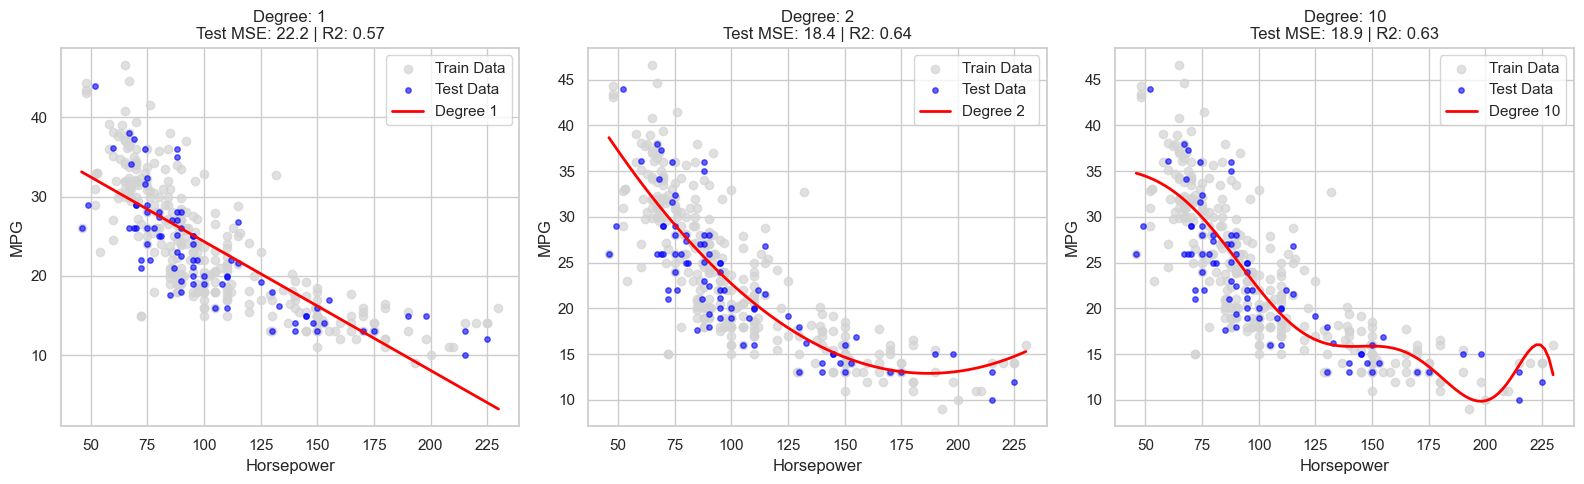

In [4]:
degrees = [1, 2, 10]
metrics = []

# Generate a smooth range of values for plotting the regression curves smoothly
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.figure(figsize=(16, 5))

for i, degree in enumerate(degrees):
    # Feature transformation
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_plot_poly = poly.transform(X_plot)
    
    # Model adjustment
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Evaluation
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    metrics.append({
        'Degree': degree,
        'Train MSE': round(train_mse, 2),
        'Test MSE': round(test_mse, 2),
        'Test R2': round(test_r2, 4)
    })
    
    # Subplots visualization
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, y_train, color='lightgray', label='Train Data', alpha=0.7)
    plt.scatter(X_test, y_test, color='blue', label='Test Data', alpha=0.6, s=15)
    plt.plot(X_plot, model.predict(X_plot_poly), color='red', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Degree: {degree}\nTest MSE: {test_mse:.1f} | R2: {test_r2:.2f}')
    plt.xlabel('Horsepower')
    plt.ylabel('MPG')
    plt.legend()

plt.tight_layout()
plt.show()

## 5. Summary Evaluation Metrics Table
Let's visualize the scores side-by-side to perform the structural diagnostics.

In [5]:
metrics_df = pd.DataFrame(metrics)
display(metrics_df)

,Degree,Train MSE,Test MSE,Test R2
0,1,24.48,22.15,0.5660
1,2,19.20,18.42,0.6392
2,10,19.47,18.94,0.6290


## 6. Model Diagnostics & Conclusions
Based on the results above, we can draw the following analysis:

1. **Degree 1 (Underfitting):** The model suffers from high bias. A linear model fails to capture the inherent non-linear curvature of the relationship, yielding high errors on both training and test data.
2. **Degree 2 (Optimal Fit):** This is the sweet spot. It captures the global curvature elegantly, leading to a dramatic reduction in Test MSE and optimizing our $R^2$ score without fitting to random noise.
3. **Degree 10 (Overfitting):** The model suffers from high variance. While it attempts to minimize Train MSE perfectly by twisting dramatically to intercept training samples, the curve becomes erratic and unstable at the boundaries. This causes the Test MSE to inflate when predicting unseen points, proving poor generalization capabilities.